### FlyWire <-> hemibrain FC1-3 co-clustering

In this notebook, we will co-clustering FC1-3 neurons from the FlyWire with those of the hemibrain dataset using `cocoa`.
This is analogous to the analyses in Figure 6 of [Schlegel et al., Nature (2024)](https://www.nature.com/articles/s41586-024-07686-5).

This is what you need:
1. Install `cocoa`: `pip install git+https://github.com/flyconnectome/cocoa.git` 
2. Generate a CAVE token. See the [caveclient docs](https://caveconnectome.github.io/CAVEclient/tutorials/authentication/) for details.
3. Create an account at https://neuprint.janelia.org/, get your API token and set as `NEUPRINT_APPLICATION_CREDENTIALS` environment variable. See the [`neuprint-python` docs](https://connectome-neuprint.github.io/neuprint-python/docs/quickstart.html) for details.

In [1]:
import cocoa as cc

We can use `cocoa` to quickly grab annotations for a given dataset:

In [2]:
ann_flywire = cc.FlyWire().get_annotations()
ann_hemibrain = cc.Hemibrain().get_annotations()

ann_flywire.head()

Caching FlyWire annotations for materialization '783'... Done.
Caching hemibrain annotations... Done.


,supervoxel_id,root_id,pos_x,pos_y,pos_z,soma_x,soma_y,soma_z,nucleus_id,flow,...,top_nt,top_nt_conf,known_nt,known_nt_source,side,nerve,vfb_id,fbbt_id,status,root_783
0,78112261444987077,720575940628857210,109306,50491,3960,104904.0,47464.0,5461.0,2453924.0,intrinsic,...,acetylcholine,0.917977,NaN,NaN,left,NaN,fw138205,FBbt_20001935,NaN,720575940628857210
1,82475466912542440,720575940626838909,172029,55635,1592,177472.0,56936.0,1429.0,7393349.0,intrinsic,...,acetylcholine,0.645442,NaN,NaN,right,NaN,fw000001,NaN,NaN,720575940626838909
2,83038623024880664,720575940626046919,180632,58664,1925,180632.0,58664.0,1925.0,7415038.0,intrinsic,...,acetylcholine,0.844781,NaN,NaN,right,NaN,fw000002,FBbt_20000538,NaN,720575940626046919
3,79801523353604463,720575940630311383,133800,56063,1847,180728.0,61008.0,1630.0,7415013.0,intrinsic,...,acetylcholine,0.760387,NaN,NaN,right,NaN,fw000003,FBbt_20000260,NaN,720575940630311383
4,83038554439606237,720575940633370649,180496,57448,2989,180496.0,57448.0,2989.0,7415848.0,intrinsic,...,acetylcholine,0.895458,NaN,NaN,right,NaN,fw000004,FBbt_00051248,NaN,720575940633370649


By default, the annotations for `FlyWire` and `Hemibrain` are downloaded and cached from the Schlegel _et al._ [Github repository](https://github.com/flyconnectome/flywire_annotations).


Co-clusterings in `cocoa` work by defining groups of neurons - one for each dataset or hemisphere - and passing them to a clustering class:

In [3]:
# Define a group of FC neurons on the LHS of FlyWire
flywire_left = cc.FlyWire(label="FwL").add_neurons(
    ann_flywire[
        (ann_flywire.side == "left")
        & ann_flywire.hemibrain_type.str.startswith("FC", na=False)
    ].root_id.values
)

# Define a group of FC neurons on the RHS of FlyWire
flywire_right = cc.FlyWire(label="FwR").add_neurons(
    ann_flywire[
        (ann_flywire.side == "right")
        & ann_flywire.hemibrain_type.str.startswith("FC", na=False)
    ].root_id.values
)

# Define a group of FC neurons on the RHS of the hemibrain dataset
hemibrain_right = cc.Hemibrain(label="HbR").add_neurons(
    ann_hemibrain[
        (ann_hemibrain.side == "right")
        & ann_hemibrain.type.str.startswith("FC", na=False)
    ].bodyId.values
)

flywire_left, flywire_right, hemibrain_right

(class FlyWire <label=FwL;neurons=116>,
 class FlyWire <label=FwR;neurons=116>,
 class Hemibrain <label=HbR;neurons=125>)

In [4]:
# Combine datasets into a Clustering object and compile the results
cl = cc.Clustering(flywire_left, flywire_right, hemibrain_right).compile()

Compiling connectivity vector for "FwL" (FlyWire) [1/3]
Compiling connectivity vector for "FwR" (FlyWire) [2/3]
Compiling connectivity vector for "HbR" (Hemibrain) [3/3]
Building across-dataset mapping for FlyWire, Hemibrain... 
  Removing 57 potentially spurious edges from the graph.
  Found 3,434 unique labels covering 47,509 neurons.
All Done.
Combining connectivity vectors...   Using 358 unique labels for clustering.
Done.
Generated a 357 by 716 observation vector.
Using on average 73.6% of neurons' synapses.
Worst case is keeping 54.3% of its synapses.
Calculating cosine distances... Done.
All done.


In [ ]:
# The connectivity vector where each row is one of our query neurons and each
# column is that neuron's connectivity to a cross-identified cell type
cl.vect_

downstream                                             \
                      hDeltaD FB9A,FB9C FB6O SMP386 LAL002 CRE025 LAL131   
720575940604064958          0         0    0      2      0      0      0   
720575940604065470          0         0    0      0      0      0      0   
720575940604709920          0         0    0      0      0      0      0   
720575940608279747          0         0    0      0      0      0      0   
720575940609370466          0         0    0      0      0      0      0   
...                       ...       ...  ...    ...    ...    ...    ...   
5813058388                  0         0    0      0      0      0      0   
5813058518                  0         0    0      7      0      0      0   
5813080632                  0         0    0      0      0      0      0   
5813099653                  0         0    0      0      0      0      0   
5813104910                  0         0    0      0      0      0      0   

                                         ... upstream                     \
                   LAL188 SMP177 CRE050  ...   CRE022 SMP150,SMP144 FB8B   
720575940604064958      0      0      0  ...        0             0    0   
720575940604065470      0      0      0  ...        0             0    0   
720575940604709920      0      0      0  ...        0             0    0   
720575940608279747      0      0      0  ...        0             0    0   
720575940609370466      0      0      0  ...        0             0    0   
...                   ...    ...    ...  ...      ...           ...  ...   
5813058388              0      0      0  ...        0             0    0   
5813058518              0      0      0  ...        0             0    0   
5813080632              0      0      0  ...        0             0    0   
5813099653              0      0      1  ...        0             0    0   
5813104910              0      0      0  ...        0             0    0   

                                                                          
                   FB5AB ATL036,ATL035 SMP143 SMP012 PS163 SMP477 MBON10  
720575940604064958     2             0      0      0     0      0      0  
720575940604065470     0             0      0      0     0      0      0  
720575940604709920    14             0      0      0     0      0      0  
720575940608279747    25             0      0      0     0      0      0  
720575940609370466     0             0      0      0     0      0      0  
...                  ...           ...    ...    ...   ...    ...    ...  
5813058388            38             0      0      0     0      0      0  
5813058518             3             0      0      0     0      0      0  
5813080632             0             0      0      0     0      0      0  
5813099653             0             0      0      0     0      0      0  
5813104910             0             0      0      0     0      0      0  

[357 rows x 716 columns]

In [ ]:
# The cosine distances - the index is the neurons' IDs and the columns are the
# neurons' type labels (if they have one)
cl.dists_

,FC2C_FwL,"FC1D,FC1E_FwL",FC2A_FwL,FC3_FwL,"FC1D,FC1E_FwL",FC1C_FwL,FC3_FwL,FC2C_FwL,"FC1A,FC1B,FC1F_FwL","FC1D,FC1E_FwL",...,FC2B_HbR,FC1C_HbR,FC2B_HbR,FC1C_HbR,FC2A_HbR,FC2B_HbR,FC2C_HbR,FC1B_HbR,FC1C_HbR,FC1E_HbR
720575940604064958,0.000000,0.975004,0.640476,0.835840,0.971906,0.831352,0.897406,0.237619,0.961625,0.933691,...,0.456290,0.946037,0.653571,0.874947,0.723650,0.545365,0.141978,0.966103,0.944401,0.939659
720575940604065470,0.975004,0.000000,0.984115,0.672117,0.020687,0.509756,0.750466,0.980234,0.263117,0.200946,...,0.971872,0.584523,0.972051,0.520547,0.976408,0.973848,0.978178,0.245980,0.598710,0.236563
720575940604709920,0.640476,0.984115,0.000000,0.866404,0.973101,0.785195,0.903007,0.568630,0.976704,0.956914,...,0.539762,0.955403,0.238325,0.867872,0.081526,0.416004,0.597748,0.977559,0.955765,0.909782
720575940608279747,0.835840,0.672117,0.866404,0.000000,0.679873,0.717641,0.148575,0.827213,0.529925,0.680845,...,0.857824,0.729028,0.853952,0.691578,0.895920,0.830351,0.855474,0.515553,0.748491,0.642221
720575940609370466,0.971906,0.020687,0.973101,0.679873,0.000000,0.484720,0.753242,0.981083,0.301790,0.167116,...,0.974371,0.540756,0.966998,0.480952,0.970080,0.973817,0.976858,0.279434,0.563787,0.202767
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5813058388,0.545365,0.973848,0.416004,0.830351,0.973817,0.863065,0.905212,0.337714,0.959584,0.941083,...,0.132674,0.953394,0.123047,0.904875,0.416987,0.000000,0.357530,0.964706,0.949847,0.945521
5813058518,0.141978,0.978178,0.597748,0.855474,0.976858,0.873589,0.910787,0.131624,0.959936,0.944854,...,0.236220,0.955455,0.526193,0.904986,0.622638,0.357530,0.000000,0.965149,0.954083,0.952841
5813080632,0.966103,0.245980,0.977559,0.515553,0.279434,0.577206,0.638409,0.975192,0.046174,0.377709,...,0.962344,0.562389,0.964384,0.482163,0.968498,0.964706,0.965149,0.000000,0.551472,0.289599
5813099653,0.944401,0.598710,0.955765,0.748491,0.563787,0.127915,0.824665,0.946194,0.727031,0.198056,...,0.954794,0.015718,0.958298,0.057615,0.957838,0.949847,0.954083,0.551472,0.000000,0.203841


The `Clustering` object has a few convenience functions for plotting & analysis:

(-0.1, 2.0)

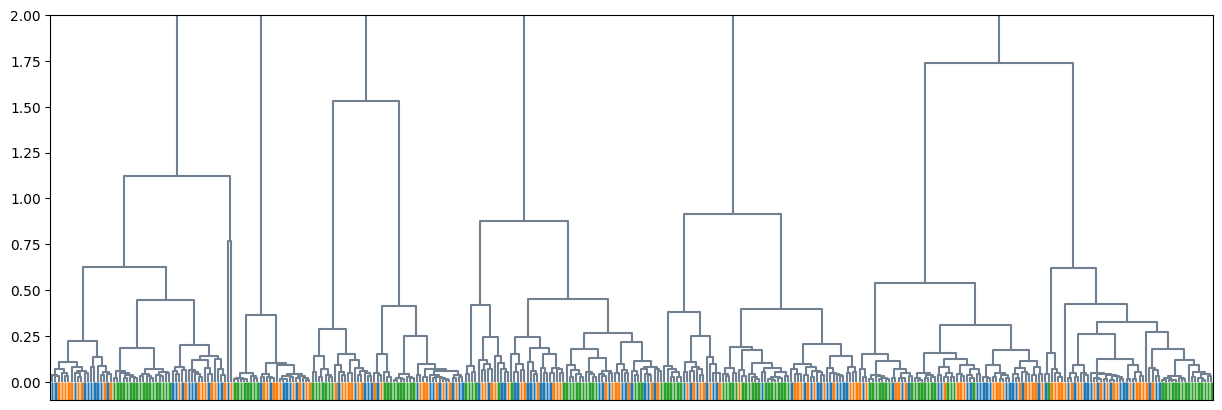

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))

# Plot a dendrogram
dn = cl.plot_dendrogram(ax=ax)

ax.set_ylim(top=2)

In above plot, each color corresponds to a dataset:
- FlyWire left/right = orange/blue
- hemibrain = green

In [ ]:
# Summarize the clustering results
# The `extract_homogeneous_clusters` will assign clusters based on a homogeneity criterion
# (i.e. each cluster has to contain neurons from each dataset in roughly equal proportions)
table = cl.to_table(clusters=cl.extract_homogeneous_clusters())
table.head()

,id,dataset,label,cn_frac_used,dend_ix,dist_ix,cluster
0,720575940627617866,FwL,FC2C,0.845626,0,77,11
1,720575940632259865,FwL,FC2C,0.846797,1,93,11
2,720575940623880013,FwR,FC2C,0.856923,2,179,11
3,720575940627901687,FwR,FC2C,0.847258,3,198,11
4,720575940613348271,FwR,FC2C,0.829909,4,134,11
